In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ValueError: mount failed

In [ ]:
import os
os.chdir("/content/drive/MyDrive/Testing_data 09 11 2025")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# --- USER CONFIGURATION ---
INPUT_FILE = '/content/drive/MyDrive/Testing_data 09 11 2025/master_kalman_input.csv'
OUTPUT_FILE = '/content/drive/MyDrive/Testing_data 09 11 2025/final_coastdown_curve.csv'

In [ ]:
def run_kalman_filter(P,Q,R,START_TIME,END_TIME):
    print("--- Loading Master Data ---")
    df = pd.read_csv(INPUT_FILE)

    # 1. TIME SLICING LOGIC
    # We use 'Time_Rel' (0, 0.05, 0.10...) because it's easier to read than Epoch.
    if START_TIME is not None and END_TIME is not None:
        print(f"Slicing data from {START_TIME}s to {END_TIME}s...")
        df = df[(df['Time_Rel'] >= START_TIME) & (df['Time_Rel'] <= END_TIME)].copy()

        if len(df) == 0:
            print("Error: No data in that time range! Check your Time_Rel column.")
            return
        df.reset_index(drop=True, inplace=True)

    # Initialize State (Velocity)
    x = df['Velocity_Meas'].iloc[0]
    filtered_vel = []

    print("--- Running Kalman Loop ---")
    for i in range(len(df)):
        # Read Inputs
        dt = df['dt'].iloc[i]
        u  = df['Accel_Meas'].iloc[i]  # Control Input (IMU)
        z  = df['Velocity_Meas'].iloc[i] # Measurement (Motor RPM)

        # --- I. PREDICTION STEP (Physics) ---
        # "My new speed is old speed + acceleration * time"
        x_pred = x + u * dt
        P_pred = P + Q

        # --- II. UPDATE STEP (Correction) ---
        # "Actually, the motor sensor says speed is Z. Let's average them."
        K = P_pred / (P_pred + R)       # Calculate Trust (Kalman Gain)
        x = x_pred + K * (z - x_pred)   # Update Estimate
        P = (1 - K) * P_pred            # Update Uncertainty

        filtered_vel.append(x)

    df['Velocity_Kalman'] = filtered_vel

    # --- III. DERIVE SMOOTH ACCELERATION ---
    # We take the derivative of the clean velocity to get the perfect drag curve.
    df['Accel_Kalman'] = np.gradient(df['Velocity_Kalman'], df['Timestamp'])

    # Save
    df.to_csv(OUTPUT_FILE, index=False)
    print(f"Filter Complete. Saved to {OUTPUT_FILE}")

    # --- PLOTTING ---
    plt.figure(figsize=(10, 10))

    # Plot 1: Velocity Fusion
    plt.subplot(2, 1, 1)
    plt.plot(df['Time_Rel'], df['Velocity_Meas'], 'k.', alpha=0.1, label='Raw Motor RPM')
    plt.plot(df['Time_Rel'], df['Velocity_Kalman'], 'b-', linewidth=2, label='Kalman Velocity')
    plt.ylabel('Speed (m/s)')
    plt.xlabel('Time (s)')
    plt.title('Step 1: Sensor Fusion (Velocity)')
    plt.legend()
    plt.grid(True)

    # Plot 2: The Coast Down Curve (Accel vs Velocity)
    plt.subplot(2, 1, 2)
    # We plot the derived Accel (Red) against the clean Velocity
    plt.scatter(df['Velocity_Kalman'], df['Accel_Kalman'], c='r', s=5, label='Filtered Data')
    plt.xlabel("Velocity (m/s)")
    plt.ylabel("Deceleration (m/s^2)")
    plt.title("Step 2: Drag Curve (Should be Parabolic)")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

    return df

In [ ]:
# --- TIME SLICING (Relative Seconds) ---
# Set to None first. Then look at the plot and set these to crop the data.
# Example: START_TIME = 10.5, END_TIME = 25.0
START_TIME = 14313.25
END_TIME = 14318.75

In [ ]:
# --- KALMAN PARAMETERS (Tuned for FS Electric) ---
# Q: Process Noise. We trust the Physics (v = v + a*dt), but allow for IMU noise.
Q = 0.005

# R: Measurement Noise. We trust the Motor RPM sensor heavily.
R = 0.9

# P: Initial Estimate Error (Converges quickly)
P = 1

--- Loading Master Data ---
Slicing data from 14313.25s to 14314.75s...
--- Running Kalman Loop ---
Filter Complete. Saved to /content/drive/MyDrive/Testing_data 09 11 2025/final_coastdown_curve.csv


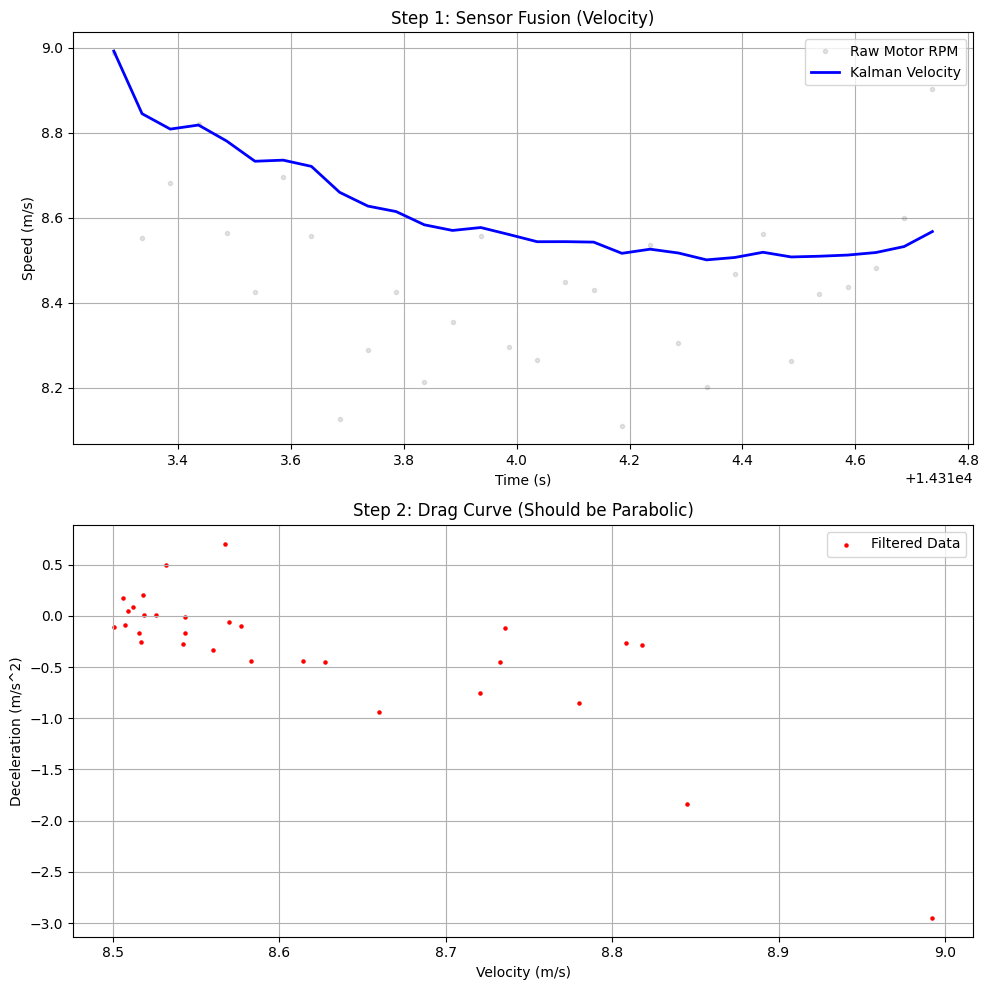

In [ ]:
kalman_filtered_df=run_kalman_filter(P,Q,R,START_TIME,END_TIME)